In [156]:
from sklearn import datasets, metrics, svm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pickle

In [157]:
digits = datasets.load_digits()

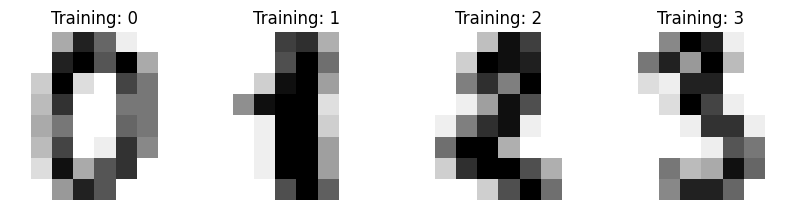

In [158]:
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title("Training: %i" % label)

In [159]:
n_samples = len(digits.images)
n_samples

1797

In [160]:
clf = svm.SVC(gamma=0.001, C=1)

In [161]:
#przygotowanie zbioru danych
datasets = digits.images.reshape((n_samples,-1))
X_train,X_test,y_train,y_test = train_test_split(datasets,digits.target,test_size=0.5,shuffle=False)
clf.fit(X_train,y_train)
predicted = clf.predict(X_test)

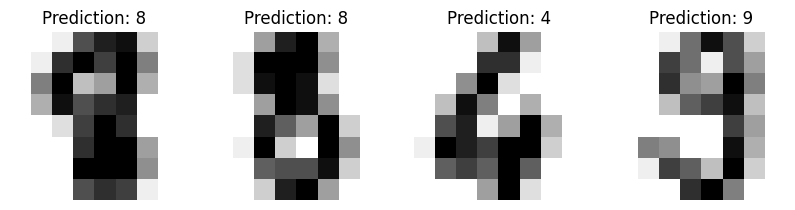

In [162]:
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, prediction in zip(axes, X_test, predicted):
    ax.set_axis_off()
    image = image.reshape(8, 8)
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title("Prediction: %i" % prediction)

In [163]:
#ocena modelu
print(f"raport klasyfikacji dla klasyfikatora {clf}\n{metrics.classification_report(y_test,predicted)}\n")

raport klasyfikacji dla klasyfikatora SVC(C=1, gamma=0.001)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.99      0.97      0.98        91
           2       0.99      0.99      0.99        86
           3       0.98      0.87      0.92        91
           4       0.99      0.96      0.97        92
           5       0.95      0.97      0.96        91
           6       0.99      0.99      0.99        91
           7       0.96      0.99      0.97        89
           8       0.94      1.00      0.97        88
           9       0.93      0.98      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899




Text(0.5, 0.98, 'Macierz pomyłek')

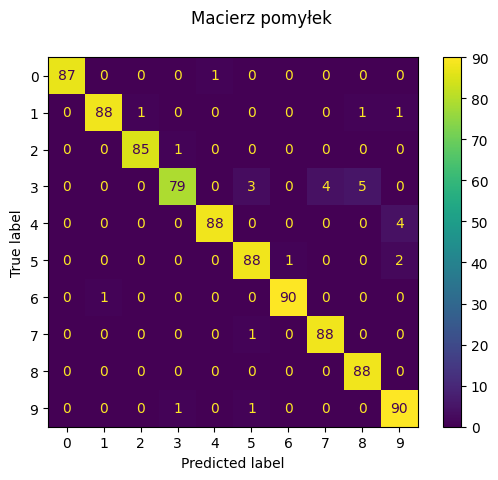

In [164]:
#macierz pomyłek
disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test,predicted)
disp.figure_.suptitle("Macierz pomyłek")